# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN From Scratch: Global Student Placement & Salary


## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from utils import (
    run_architecture_experiments,
    run_learning_rate_experiments,
    plot_train_val_curves,
    plot_prediction_bars,
    analyze_results_distributions,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load and Explore the Dataset

In [2]:
DATA_PATH = '../data/student_placement_salary.csv'

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
 cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [4]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


college_tier:
college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
----------------------------------------

country:
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
----------------------------------------

university_ranking_band:
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
----------------------------------------

specialization:
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
----------------------------------------

industry:
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
----------------------------------------

placement_status:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
--

## 3. Data Preprocessing

In [5]:
TARGET_COL  = 'placement_status'   

df = df.dropna(subset=[TARGET_COL])

# 2. Encode categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

label_cols = ['college_tier', 'university_ranking_band']
ohe_cols = [o for o in cat_cols if o not in label_cols]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# 3. Encode target
y_raw = le.fit_transform(df[TARGET_COL].astype(str))
n_classes = len(np.unique(y_raw))

if n_classes == 2:
    # Binary classification → sigmoid + BCE
    y = y_raw.reshape(-1, 1).astype(float)
    TASK = 'binary'
else:
    # Multi-class → softmax + CCE (one-hot)
    y = np.eye(n_classes)[y_raw]
    TASK = 'multiclass'

print(f"Task: {TASK}, classes: {n_classes}, y shape: {y.shape}")

# 4. Feature matrix
X_df = df.drop(columns=[TARGET_COL])
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values).astype(float)
print(f"X shape: {X.shape}")

# 5. Train / validation / test split  (60 / 20 / 20)
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Task: binary, classes: 2, y shape: (10000, 1)
X shape: (10000, 8)
Train: (6000, 8), Val: (2000, 8), Test: (2000, 8)


## 4. Model Testing


### 4.1 Hyperparameter

#### 4.1.1 Depth and Width Parameter

In [6]:
n_features = X_train.shape[1]
n_out      = y_train.shape[1]

experiments = {
    # Width Variations (depth = 2 tetap)
    'Width_Small': [
        {'n_in': n_features,  'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': 16, 'activation': 'relu'},
        {'n_in': 16, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Medium': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Large': [
        {'n_in': n_features,   'n_out': 128, 'activation': 'relu'},
        {'n_in': 128, 'n_out': 64,  'activation': 'relu'},
        {'n_in': 64,  'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    
    # Depth Variations (width = 64 tetap)
    'Depth_1': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_2': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_3': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
}


In [7]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

results = run_architecture_experiments(
    experiments=experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Width_Small
  Layer 1: DenseLayer(8 → 32, activation=ReLU)  [288 params]
  Layer 2: DenseLayer(32 → 16, activation=ReLU)  [528 params]
  Layer 3: DenseLayer(16 → 1, activation=Sigmoid)  [17 params]
----------------------------------------------------
  Total params: 833
Epoch   20/200  loss: 0.672784  val_loss: 0.676101
Epoch   40/200  loss: 0.664101  val_loss: 0.669383
Epoch   60/200  loss: 0.658649  val_loss: 0.665004
Epoch   80/200  loss: 0.653877  val_loss: 0.661163
Epoch  100/200  loss: 0.649311  val_loss: 0.656925
Epoch  120/200  loss: 0.644002  val_loss: 0.651733
Epoch  140/200  loss: 0.637679  val_loss: 0.645214
Epoch  160/200  loss: 0.630202  val_loss: 0.637011
Epoch  180/200  loss: 0.620711  val_loss: 0.627055
Epoch  200/200  loss: 0.610053  val_loss: 0.615323

Width_Small - Test Loss: 0.6110, Accuracy: 0.6125

Running: Width_Medium
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 32, activation=ReLU)  [2,080 params]
  Layer 3:

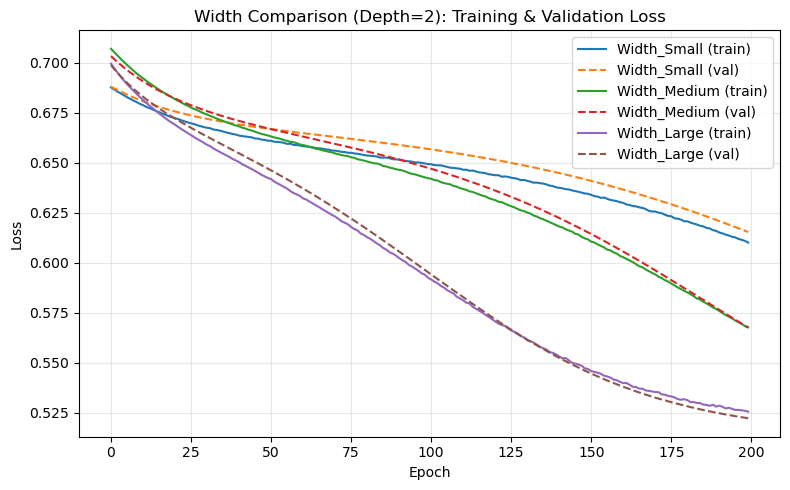

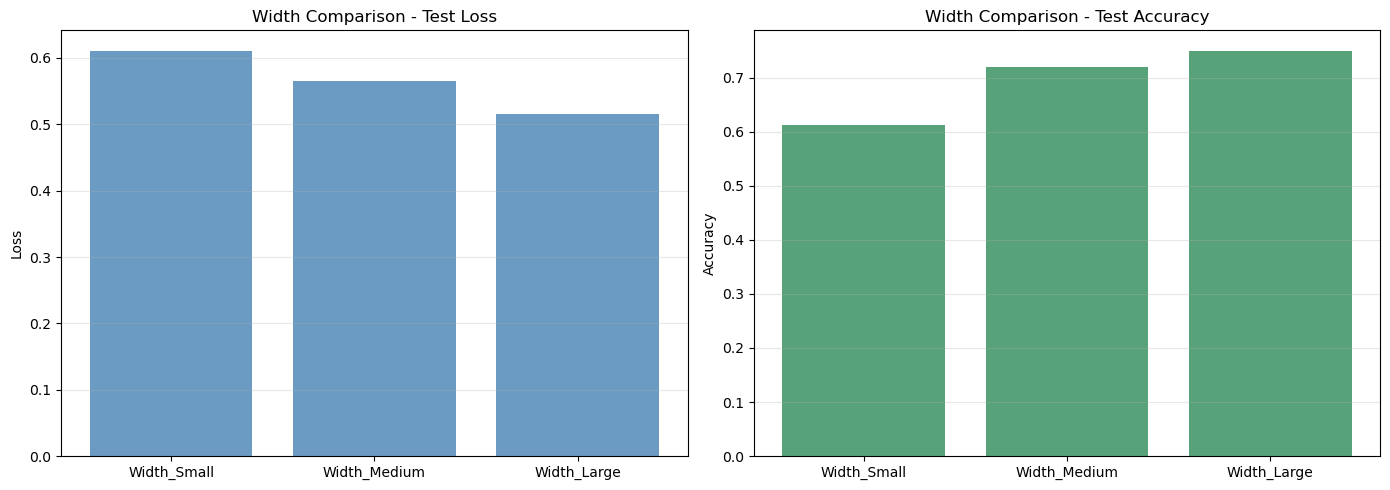

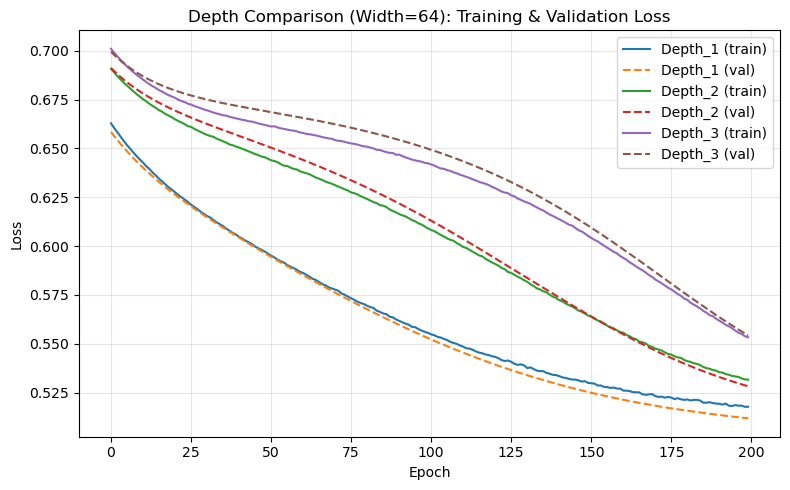

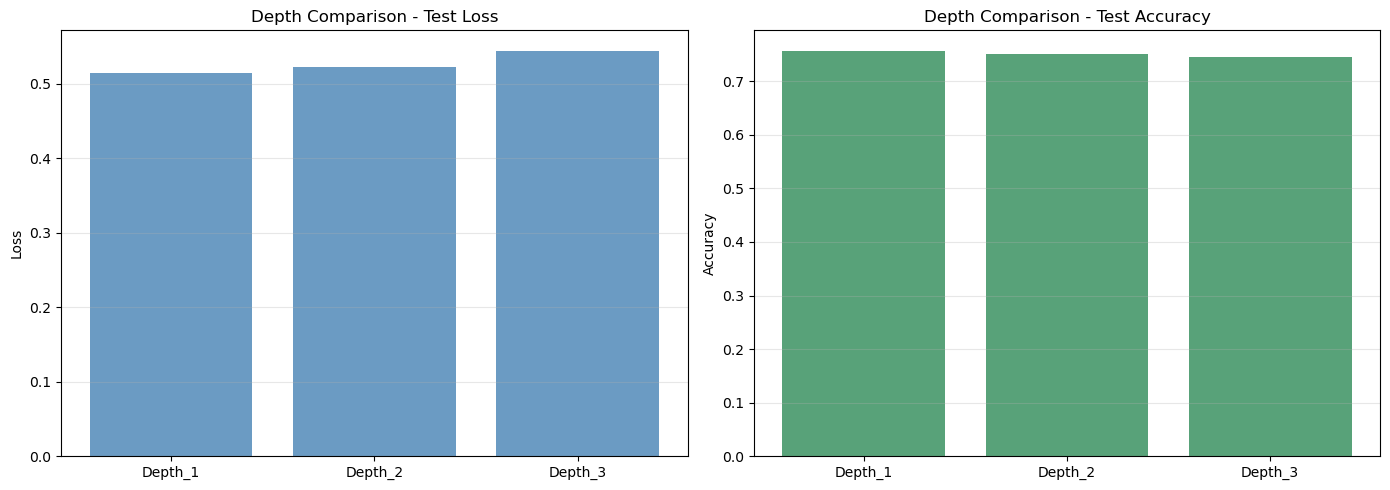

In [8]:
width_results = {k: results[k] for k in ['Width_Small', 'Width_Medium', 'Width_Large']}
depth_results = {k: results[k] for k in ['Depth_1', 'Depth_2', 'Depth_3']}

plot_train_val_curves(
    width_results,
    title='Width Comparison (Depth=2): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    width_results,
    title_prefix='Width Comparison',
)

plot_train_val_curves(
    depth_results,
    title='Depth Comparison (Width=64): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    depth_results,
    title_prefix='Depth Comparison',
)

### 4.1.2 Fungsi Aktivasi

In [9]:
BASE_ARCH = [128, 64]

activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']

activation_experiments = {}

for act_name in activation_functions:
    config = []
    
    # Hidden Layer 1
    config.append({
        'n_in': n_features,
        'n_out': BASE_ARCH[0],
        'activation': act_name
    })
    
    # Hidden Layer 2
    config.append({
        'n_in': BASE_ARCH[0],
        'n_out': BASE_ARCH[1],
        'activation': act_name 
    })
    
    # Output Layer
    config.append({
        'n_in': BASE_ARCH[1],
        'n_out': n_out,
        'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'
    })
    
    activation_experiments[f'Act_{act_name.capitalize()}'] = config

print("Activation Function Experiments:")
for name, config in activation_experiments.items():
    hidden_act = config[0]['activation']
    print(f"  {name}: Hidden layers use '{hidden_act}' activation")

Activation Function Experiments:
  Act_Linear: Hidden layers use 'linear' activation
  Act_Relu: Hidden layers use 'relu' activation
  Act_Sigmoid: Hidden layers use 'sigmoid' activation
  Act_Tanh: Hidden layers use 'tanh' activation


In [10]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

activation_results = run_architecture_experiments(
    experiments=activation_experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Act_Linear
  Layer 1: DenseLayer(8 → 128, activation=Linear)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=Linear)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch   20/200  loss: 0.576231  val_loss: 0.571937
Epoch   40/200  loss: 0.536888  val_loss: 0.530701
Epoch   60/200  loss: 0.524810  val_loss: 0.518029
Epoch   80/200  loss: 0.521308  val_loss: 0.514052
Epoch  100/200  loss: 0.520466  val_loss: 0.512623
Epoch  120/200  loss: 0.520583  val_loss: 0.512017
Epoch  140/200  loss: 0.520097  val_loss: 0.511727
Epoch  160/200  loss: 0.520034  val_loss: 0.511548
Epoch  180/200  loss: 0.520012  val_loss: 0.511427
Epoch  200/200  loss: 0.520508  val_loss: 0.511338

Act_Linear - Test Loss: 0.5062, Accuracy: 0.7580

Running: Act_Relu
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]


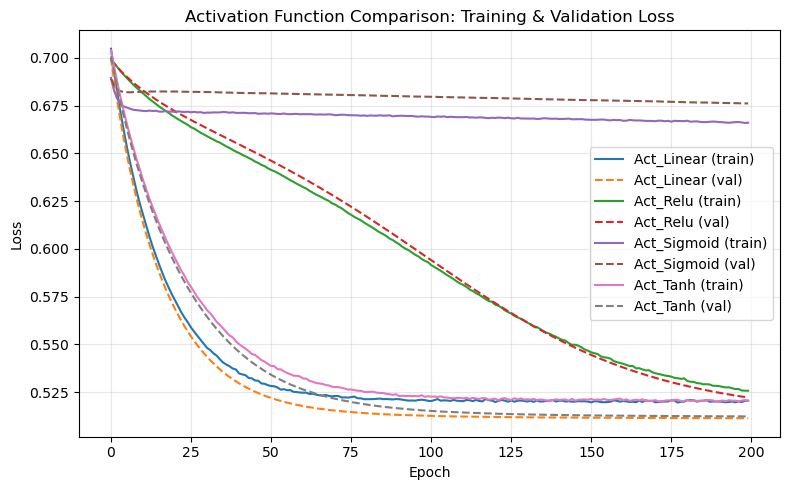

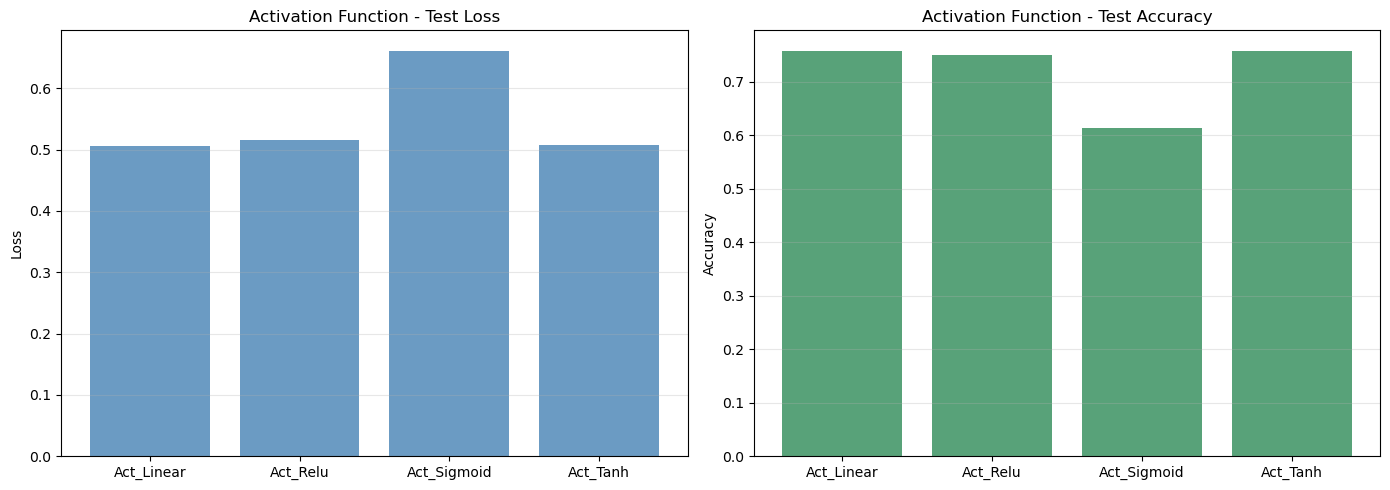

In [11]:
plot_train_val_curves(
    activation_results,
    title='Activation Function Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    activation_results,
    title_prefix='Activation Function',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Linear
Test Accuracy: 0.7580

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003790 | Std: 0.096870
  Min: -0.351186 | Max: 0.309532
  Median: -0.002299

Layer 1:
  Shape: (128, 64)
  Mean: -0.000731 | Std: 0.096891
  Min: -0.426724 | Max: 0.391635
  Median: -0.000482

Layer 2:
  Shape: (64, 1)
  Mean: 0.002295 | Std: 0.114319
  Min: -0.253550 | Max: 0.266991
  Median: 0.001854

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000005 | Std: 0.001105
  Min: -0.006641 | Max: 0.006634
  Median: 0.000000
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

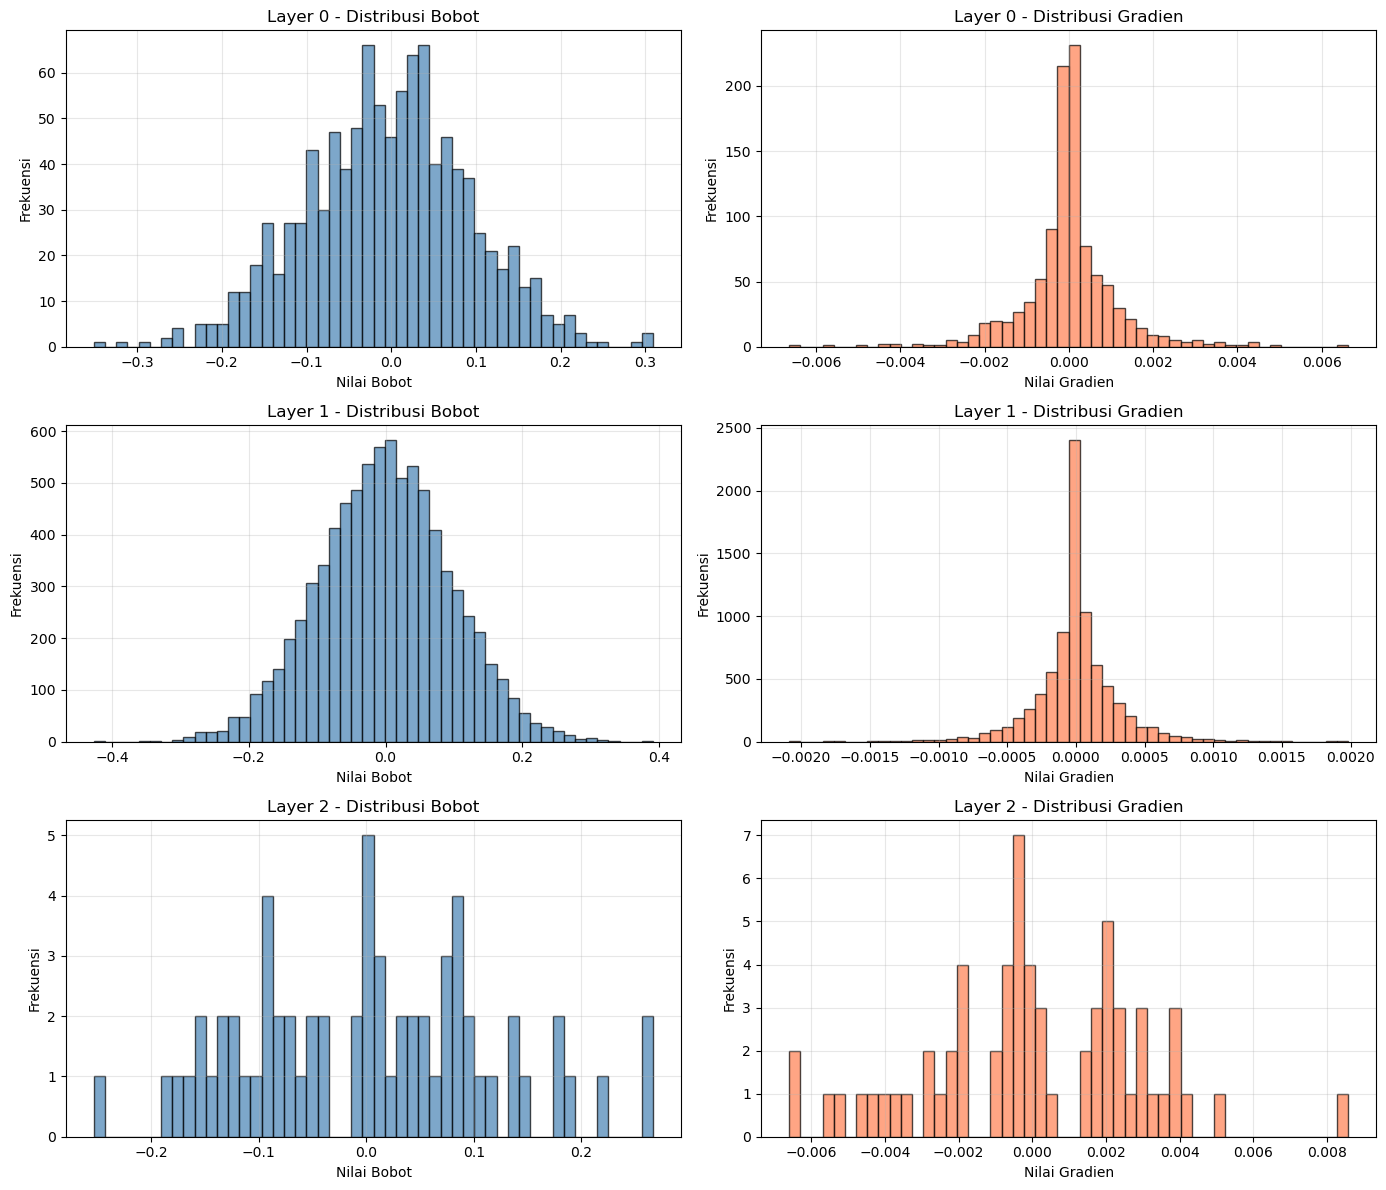


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Relu
Test Accuracy: 0.7500

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002060 | Std: 0.099233
  Min: -0.365071 | Max: 0.358881
  Median: -0.001157

Layer 1:
  Shape: (128, 64)
  Mean: 0.001051 | Std: 0.097233
  Min: -0.422721 | Max: 0.401105
  Median: 0.001085

Layer 2:
  Shape: (64, 1)
  Mean: 0.017337 | Std: 0.147222
  Min: -0.355847 | Max: 0.385931
  Median: 0.008448

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000042 | Std: 0.000646
  Min: -0.005153 | Max: 0.004406
  Median: -0.000027
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

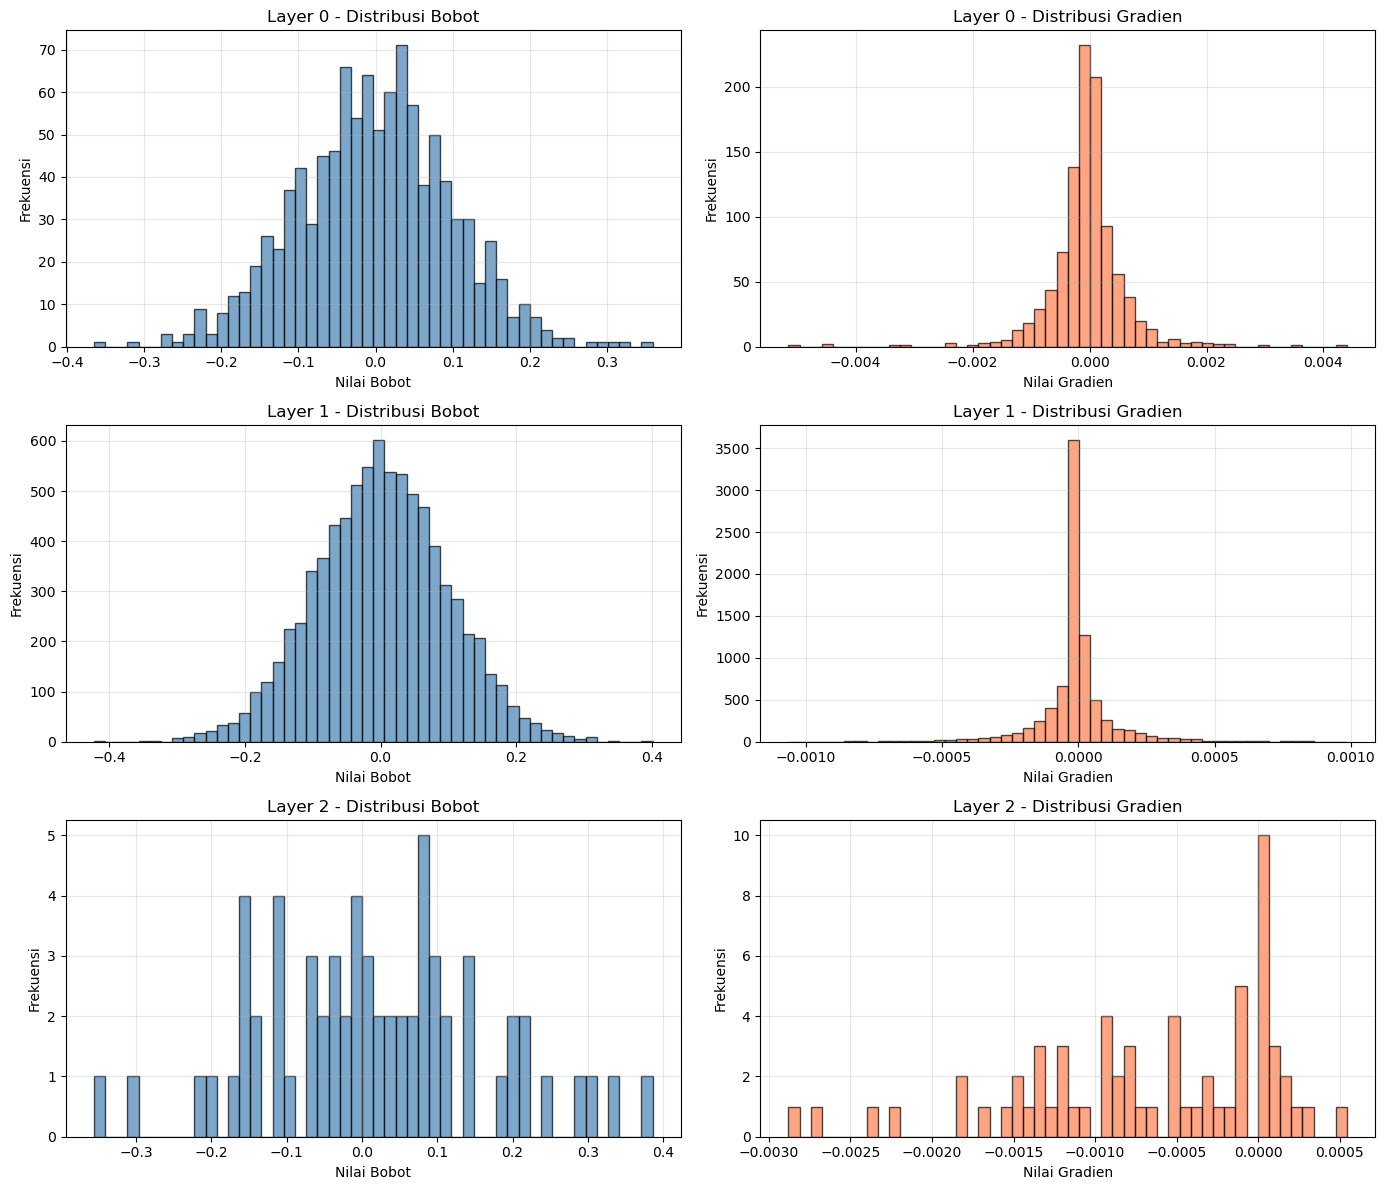


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Sigmoid
Test Accuracy: 0.6125

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002924 | Std: 0.095034
  Min: -0.351158 | Max: 0.306685
  Median: 0.000151

Layer 1:
  Shape: (128, 64)
  Mean: -0.000689 | Std: 0.096645
  Min: -0.423082 | Max: 0.389355
  Median: -0.001180

Layer 2:
  Shape: (64, 1)
  Mean: 0.015613 | Std: 0.082400
  Min: -0.165515 | Max: 0.225815
  Median: 0.021232

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000001 | Std: 0.000059
  Min: -0.000457 | Max: 0.000251
  Median: -0.000000
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

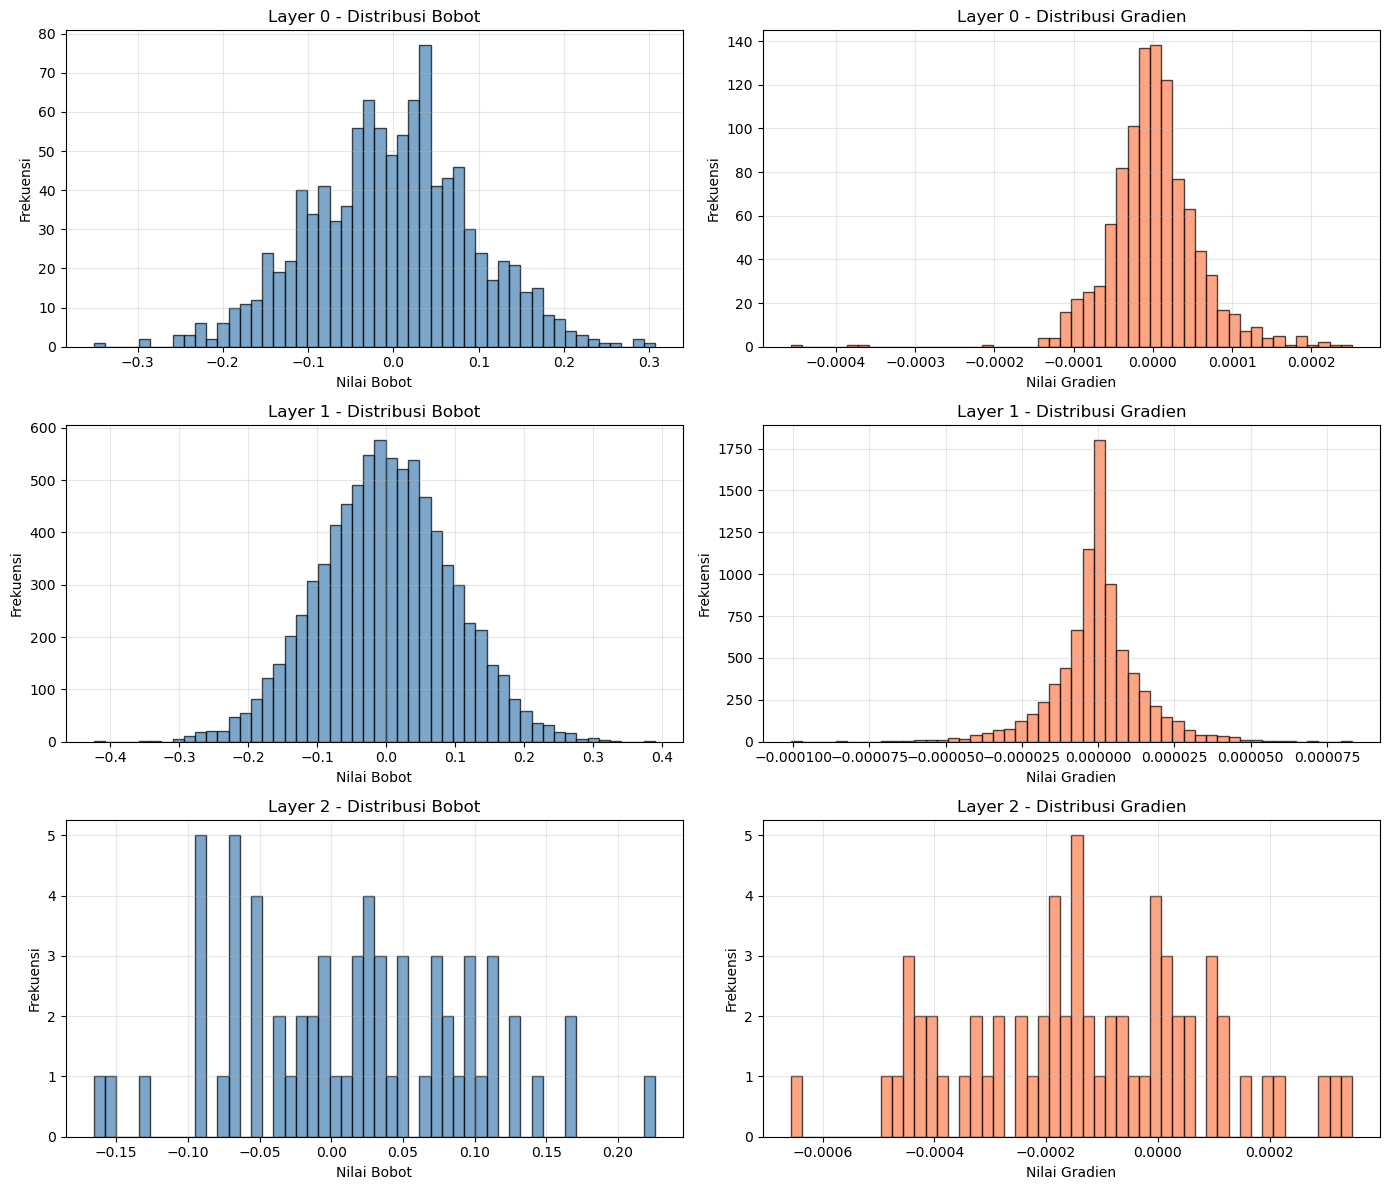


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Tanh
Test Accuracy: 0.7565

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003731 | Std: 0.096616
  Min: -0.349041 | Max: 0.310114
  Median: -0.002116

Layer 1:
  Shape: (128, 64)
  Mean: -0.000720 | Std: 0.096902
  Min: -0.427768 | Max: 0.391901
  Median: -0.000569

Layer 2:
  Shape: (64, 1)
  Mean: 0.000405 | Std: 0.123824
  Min: -0.270976 | Max: 0.285672
  Median: 0.002447

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000043 | Std: 0.000706
  Min: -0.003960 | Max: 0.005131
  Median: -0.000025
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

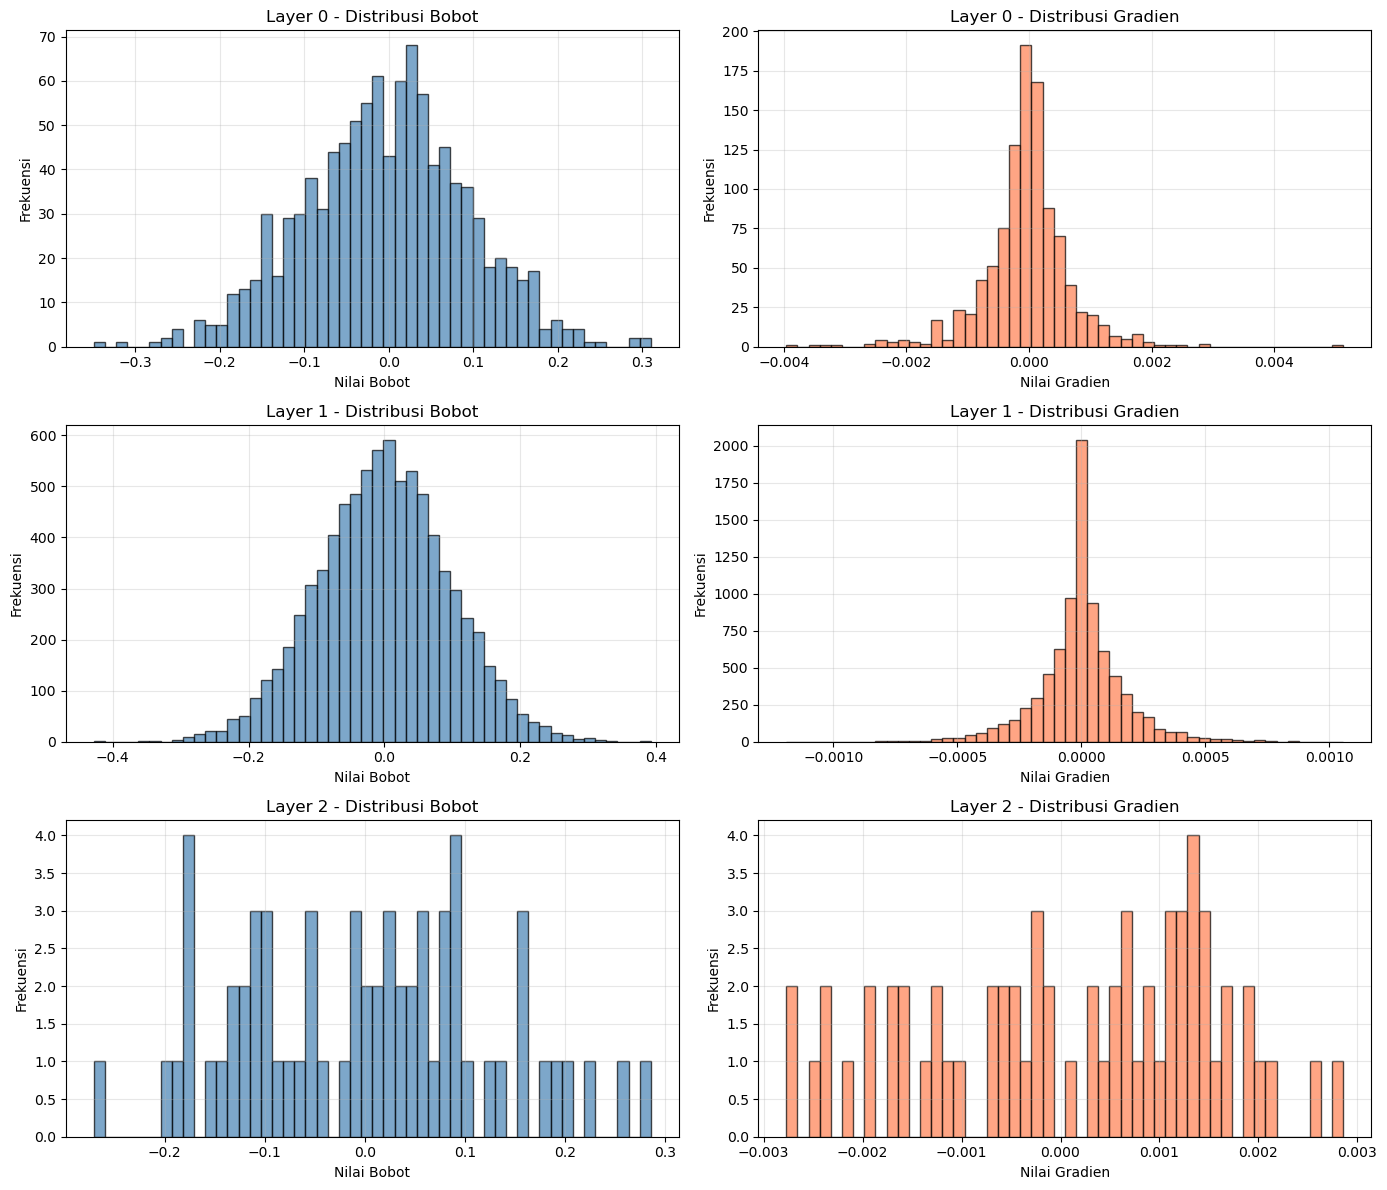

In [12]:
analyze_results_distributions(
    activation_results,
    result_group_name='Activation',
)

### 4.1.3 Learning Rate

In [13]:
learning_rates = {
    'LR_0.001': 0.001,
    'LR_0.01': 0.01,
    'LR_0.1': 0.1,
}

BASE_LR_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

lr_results = run_learning_rate_experiments(
    learning_rates=learning_rates,
    base_arch=BASE_LR_ARCH,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: LR_0.001 (lr=0.001)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch   20/200  loss: 0.696356  val_loss: 0.696912
Epoch   40/200  loss: 0.692238  val_loss: 0.693301
Epoch   60/200  loss: 0.688572  val_loss: 0.690031
Epoch   80/200  loss: 0.685192  val_loss: 0.687053
Epoch  100/200  loss: 0.682196  val_loss: 0.684320
Epoch  120/200  loss: 0.679283  val_loss: 0.681784
Epoch  140/200  loss: 0.676644  val_loss: 0.679414
Epoch  160/200  loss: 0.674061  val_loss: 0.677184
Epoch  180/200  loss: 0.671864  val_loss: 0.675075
Epoch  200/200  loss: 0.669487  val_loss: 0.673065

LR_0.001 - Test Loss: 0.6610, Accuracy: 0.6190

Running: LR_0.01 (lr=0.01)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,

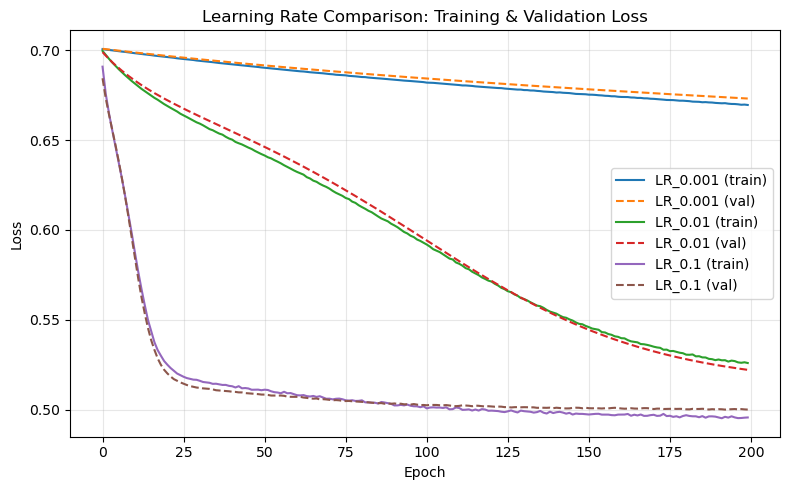

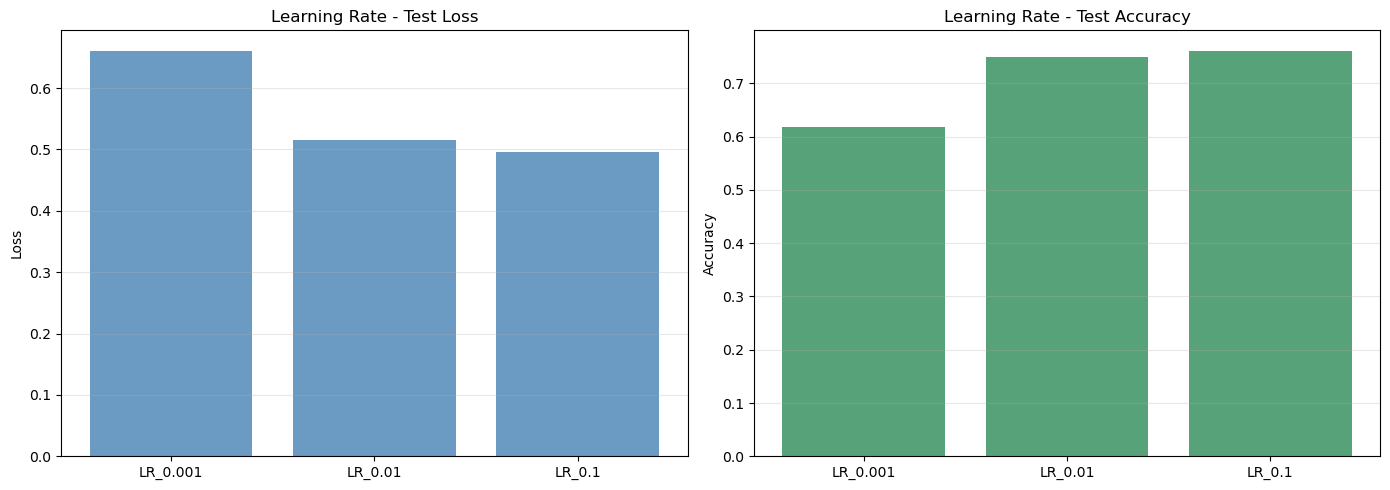

In [14]:
plot_train_val_curves(
    lr_results,
    title='Learning Rate Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    lr_results,
    title_prefix='Learning Rate',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.001
Test Accuracy: 0.6190

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002967 | Std: 0.098021
  Min: -0.363702 | Max: 0.317472
  Median: 0.000484

Layer 1:
  Shape: (128, 64)
  Mean: -0.000712 | Std: 0.099940
  Min: -0.437265 | Max: 0.402150
  Median: -0.000974

Layer 2:
  Shape: (64, 1)
  Mean: 0.011372 | Std: 0.079122
  Min: -0.161938 | Max: 0.214470
  Median: 0.017469

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000000 | Std: 0.000181
  Min: -0.000701 | Max: 0.000704
  Median: 0.000003
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

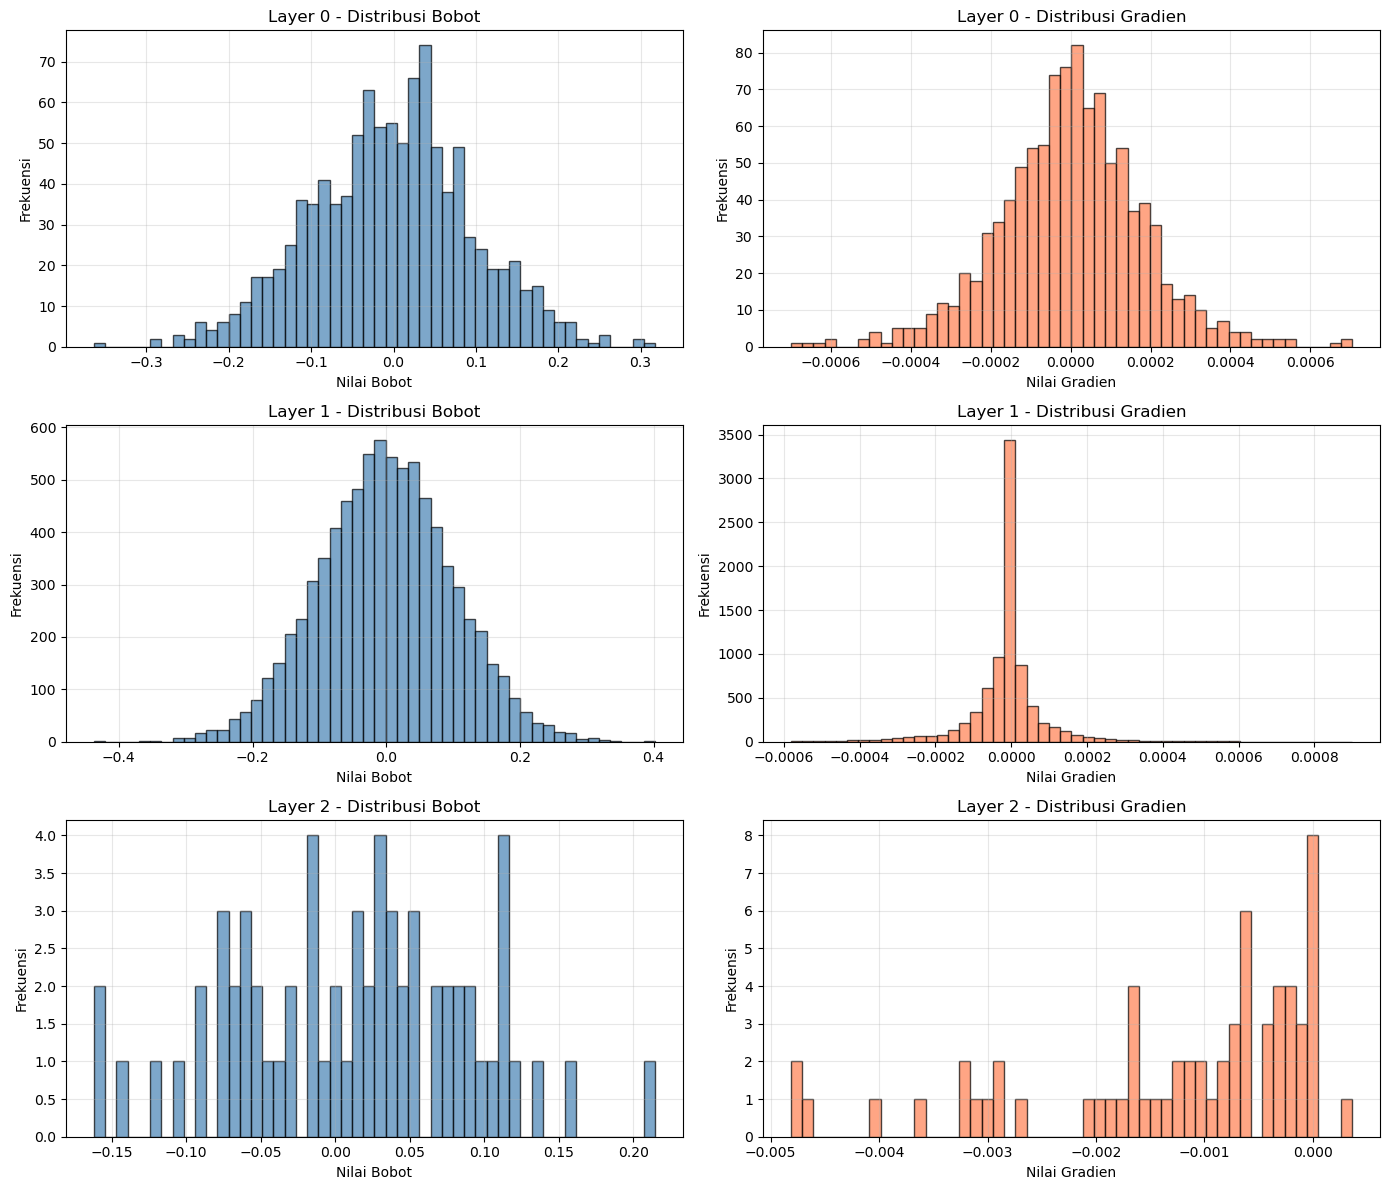


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.01
Test Accuracy: 0.7490

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002061 | Std: 0.099234
  Min: -0.365094 | Max: 0.359044
  Median: -0.001139

Layer 1:
  Shape: (128, 64)
  Mean: 0.001052 | Std: 0.097233
  Min: -0.422721 | Max: 0.401094
  Median: 0.001081

Layer 2:
  Shape: (64, 1)
  Mean: 0.017349 | Std: 0.147231
  Min: -0.355774 | Max: 0.385888
  Median: 0.008538

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000022 | Std: 0.000649
  Min: -0.004144 | Max: 0.004703
  Median: 0.000020
  % Zero Gradients: 0.78%

Layer 1:
  Shape: (128

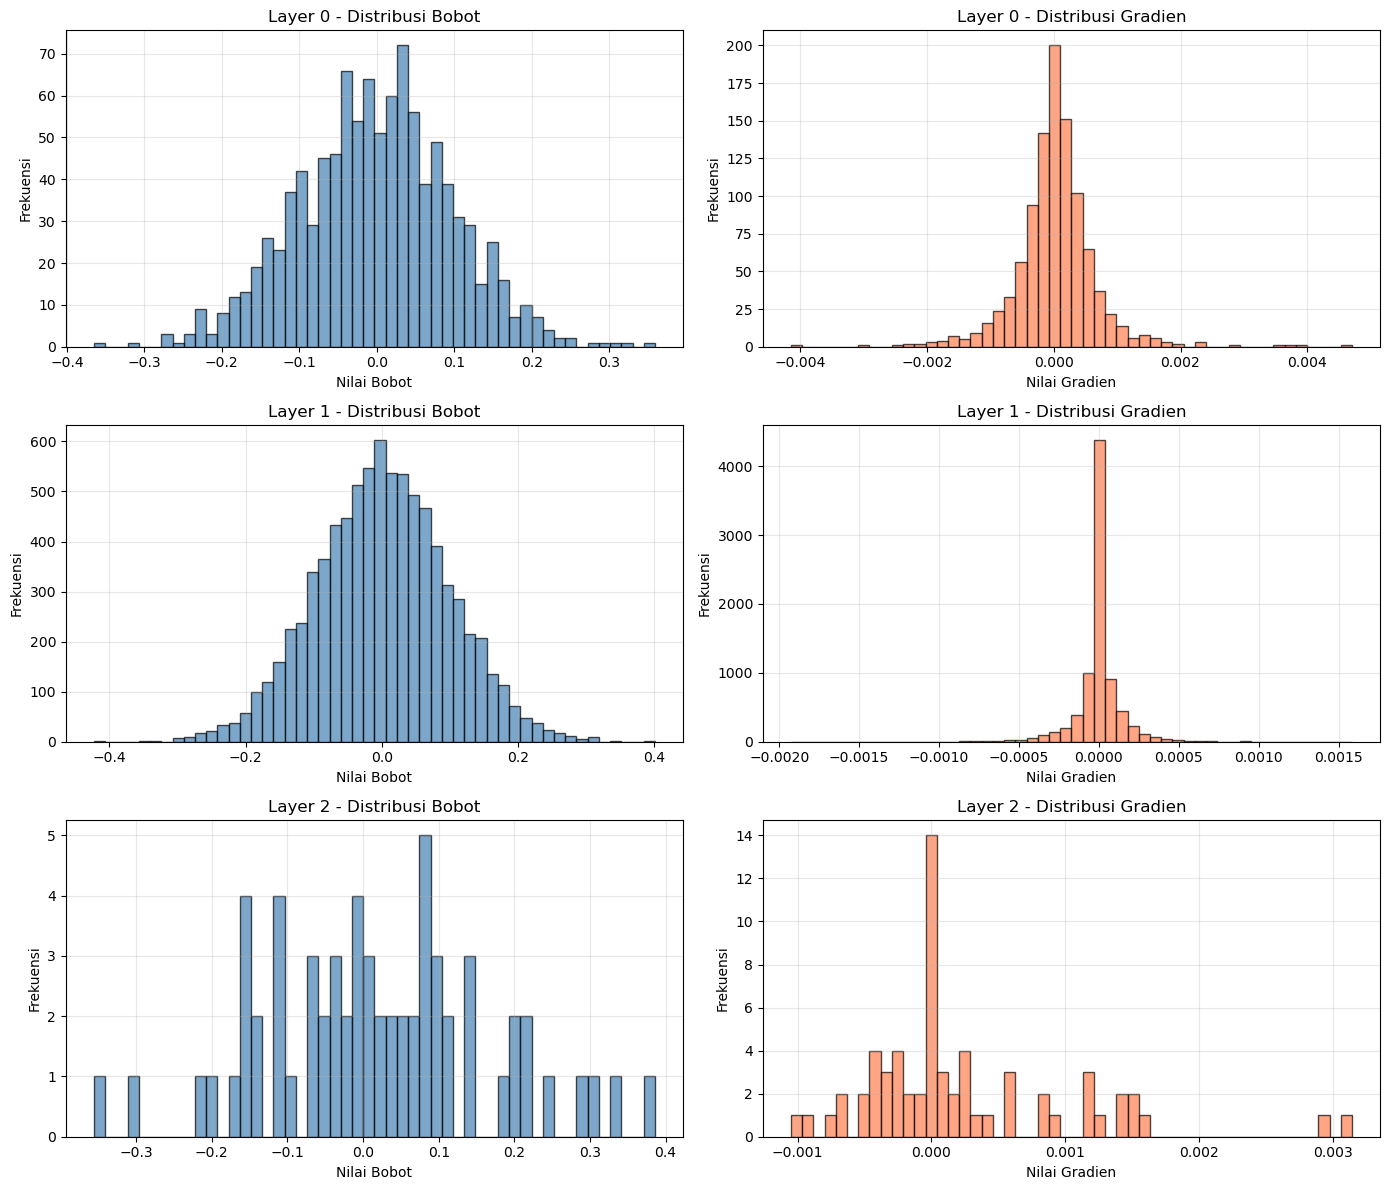


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.1
Test Accuracy: 0.7615

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001626 | Std: 0.081761
  Min: -0.316722 | Max: 0.472048
  Median: -0.001289

Layer 1:
  Shape: (128, 64)
  Mean: 0.002409 | Std: 0.070769
  Min: -0.301359 | Max: 0.300199
  Median: 0.002051

Layer 2:
  Shape: (64, 1)
  Mean: 0.022048 | Std: 0.194374
  Min: -0.431593 | Max: 0.503065
  Median: 0.003821

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000021 | Std: 0.000607
  Min: -0.002423 | Max: 0.002568
  Median: -0.000005
  % Zero Gradients: 0.78%

Layer 1:
  Shape: (12

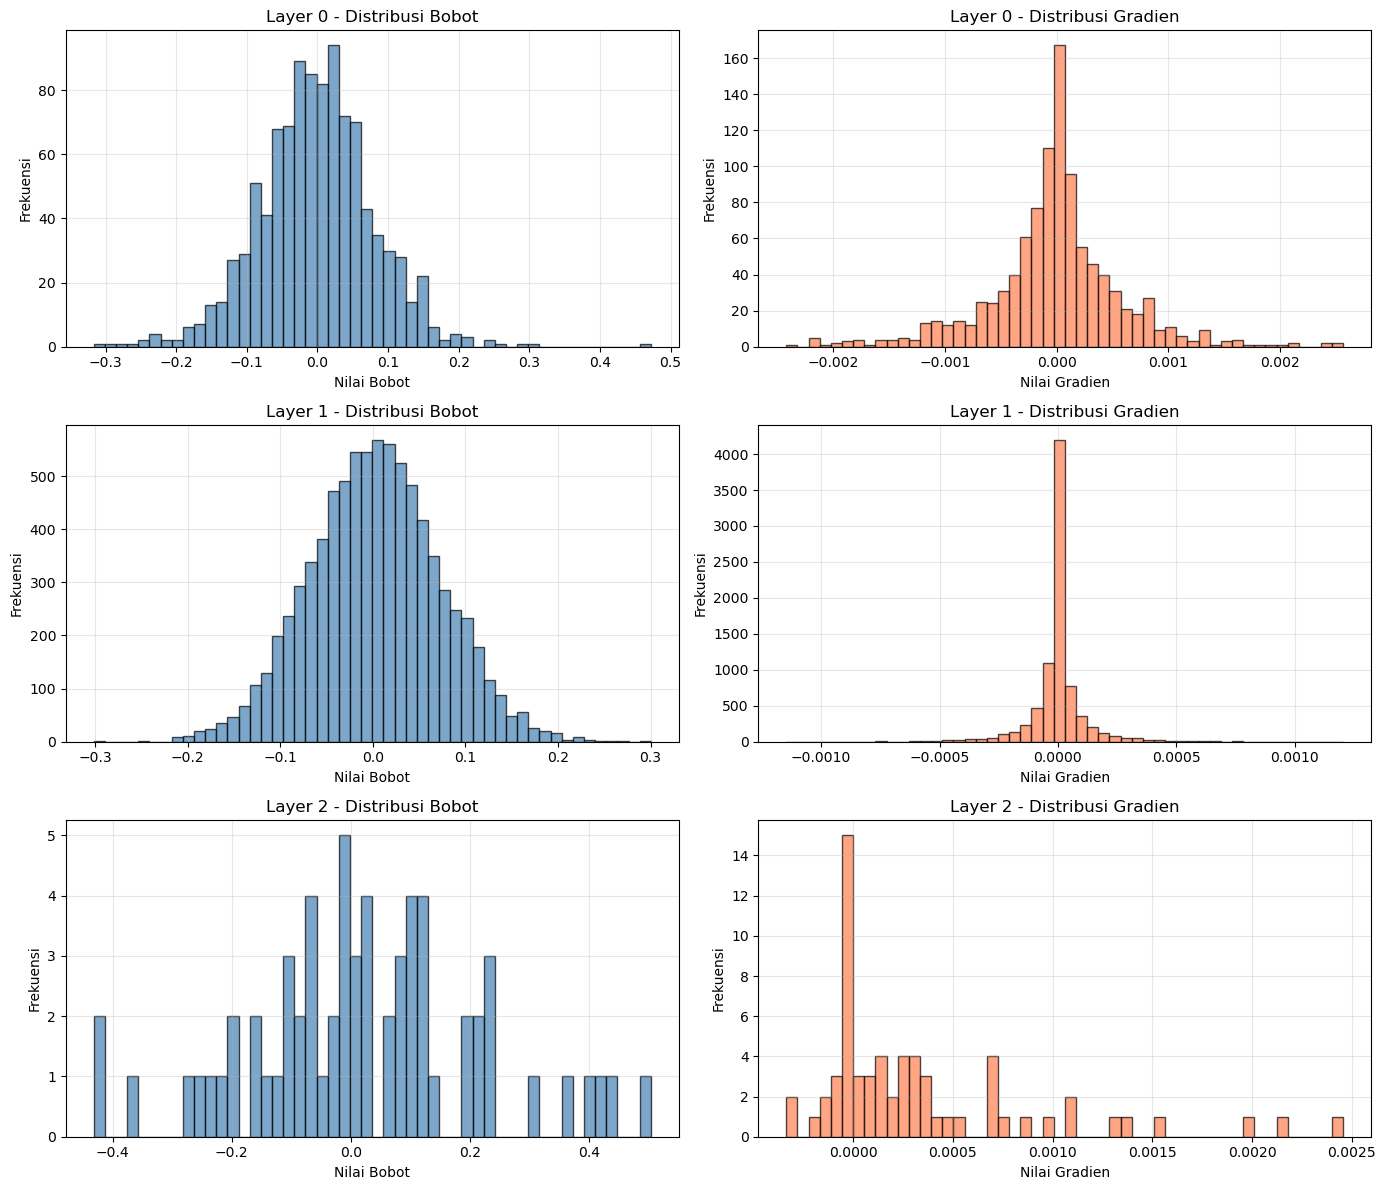

In [15]:
analyze_results_distributions(
    lr_results,
    result_group_name='Learning Rate',
)

### 4.1.4 Pengaruh Inisialisasi Bobot

Memulai Eksperimen Inisialisasi Bobot...

Menguji Inisialisasi: ZERO

Running: zero
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

zero - Test Loss: 0.6676, Accuracy: 0.6125

Menguji Inisialisasi: RANDOM_UNIFORM

Running: random_uniform
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_uniform - Test Loss: 0.5437, Accuracy: 0.6920

Menguji Inisialisasi: RANDOM_NORMAL

Running: random_normal
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_normal - Test Loss: 0.6746, Accuracy: 0.7185


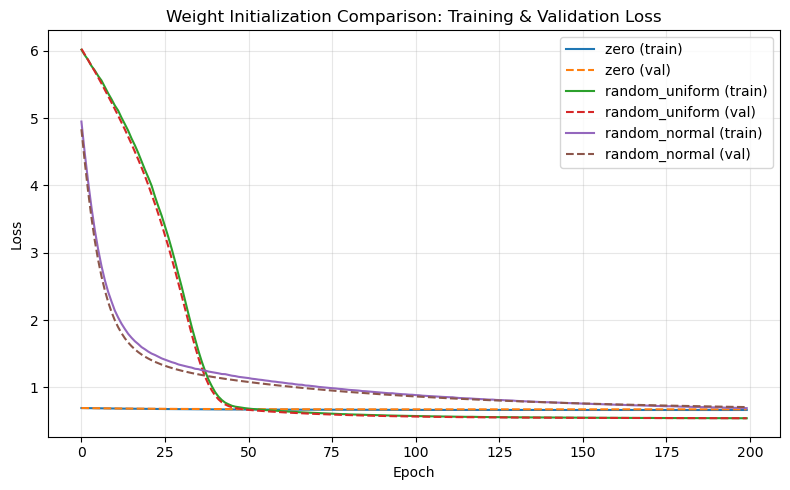

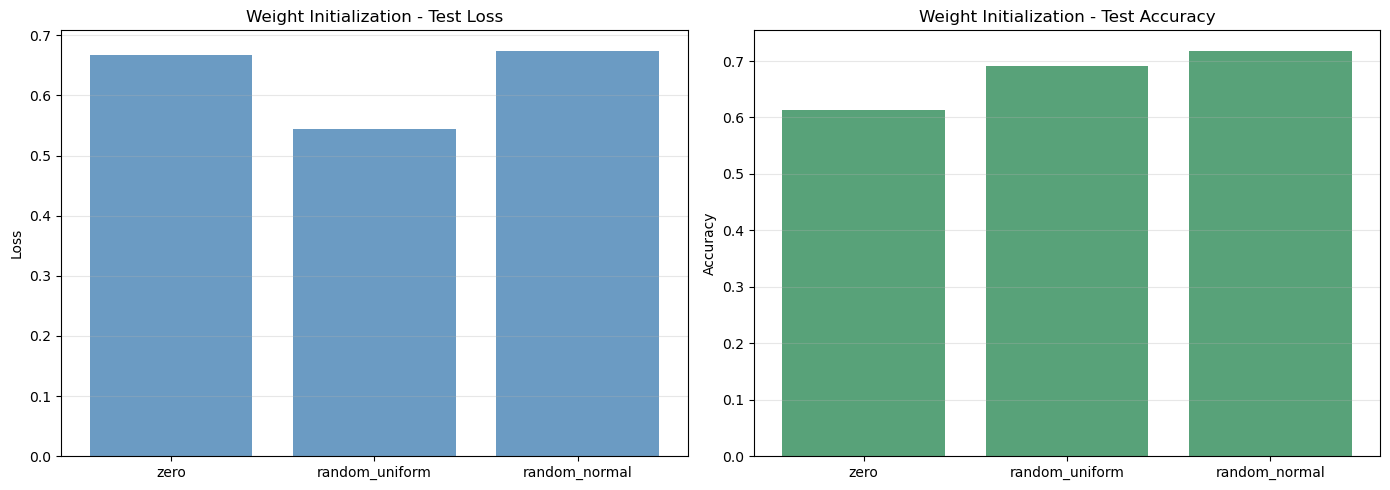

In [16]:
print("Memulai Eksperimen Inisialisasi Bobot...")

init_methods = ['zero', 'random_uniform', 'random_normal']
init_results = {}

last_act = 'softmax' if TASK == 'multiclass' else 'sigmoid'
arch_for_init = [
    {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': last_act},
]

for method in init_methods:
    print(f"\n============================================================")
    print(f"Menguji Inisialisasi: {method.upper()}")
    print(f"============================================================")
    
    temp_exp = {method: arch_for_init}
    init_dict = {'init_method': method} 
    
    res = run_architecture_experiments(
        experiments=temp_exp,
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,        
        lr=0.01, 
        regularization='none',
        epochs=200,
        batch_size=32,
        verbose=0,             
    )
    init_results[method] = res[method]


plot_train_val_curves(init_results, title='Weight Initialization Comparison: Training & Validation Loss')

plot_prediction_bars(init_results, title_prefix='Weight Initialization')

## 4.2 Pengaruh Regularisasi


Running: Reg_None
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch   20/200  loss: 0.660603  val_loss: 0.663678
Epoch   40/200  loss: 0.641389  val_loss: 0.645724
Epoch   60/200  loss: 0.622804  val_loss: 0.627395
Epoch   80/200  loss: 0.602647  val_loss: 0.606114
Epoch  100/200  loss: 0.580470  val_loss: 0.582501
Epoch  120/200  loss: 0.559066  val_loss: 0.559374
Epoch  140/200  loss: 0.540999  val_loss: 0.539975
Epoch  160/200  loss: 0.527942  val_loss: 0.525931
Epoch  180/200  loss: 0.520429  val_loss: 0.516756
Epoch  200/200  loss: 0.515478  val_loss: 0.511226

Reg_None - Test Loss: 0.5138, Accuracy: 0.7505

Running: Reg_L1
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3:

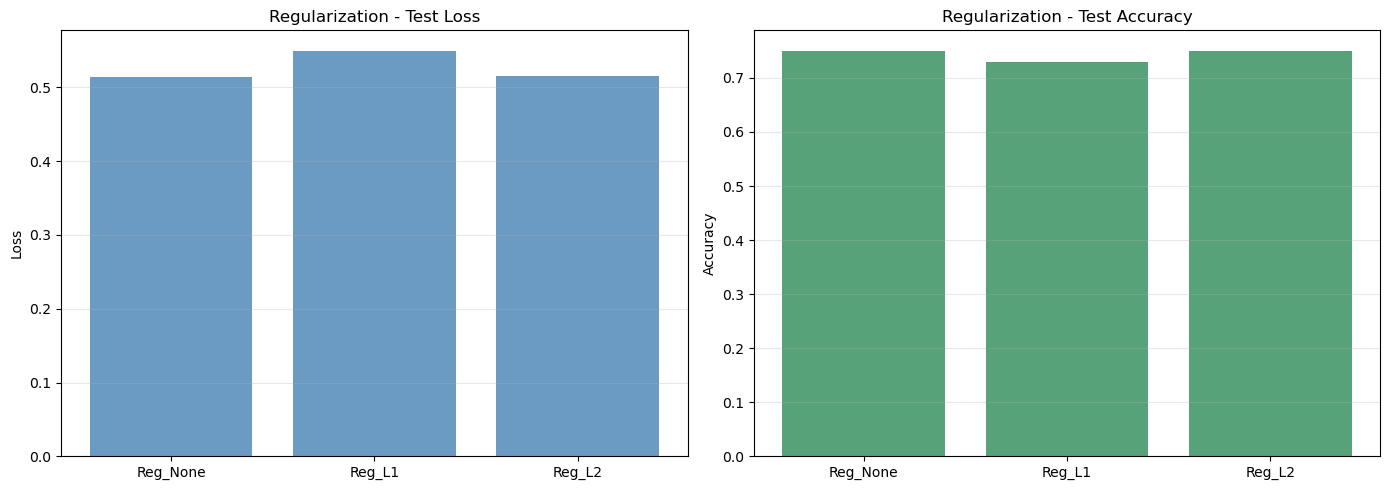

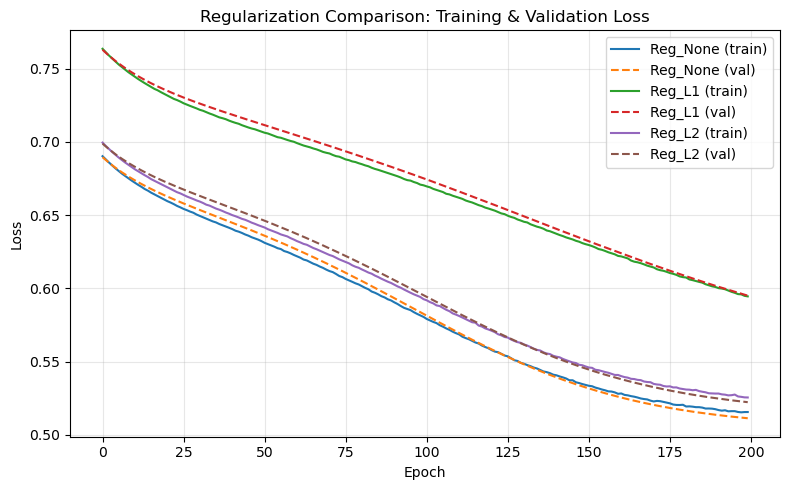


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_None
Test Accuracy: 0.7505

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002177 | Std: 0.102789
  Min: -0.378582 | Max: 0.368603
  Median: -0.001254

Layer 1:
  Shape: (128, 64)
  Mean: 0.001022 | Std: 0.100922
  Min: -0.438918 | Max: 0.415708
  Median: 0.001116

Layer 2:
  Shape: (64, 1)
  Mean: 0.017820 | Std: 0.149486
  Min: -0.360610 | Max: 0.388595
  Median: 0.006889

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000020 | Std: 0.000705
  Min: -0.003753 | Max: 0.003608
  Median: 0.000001
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

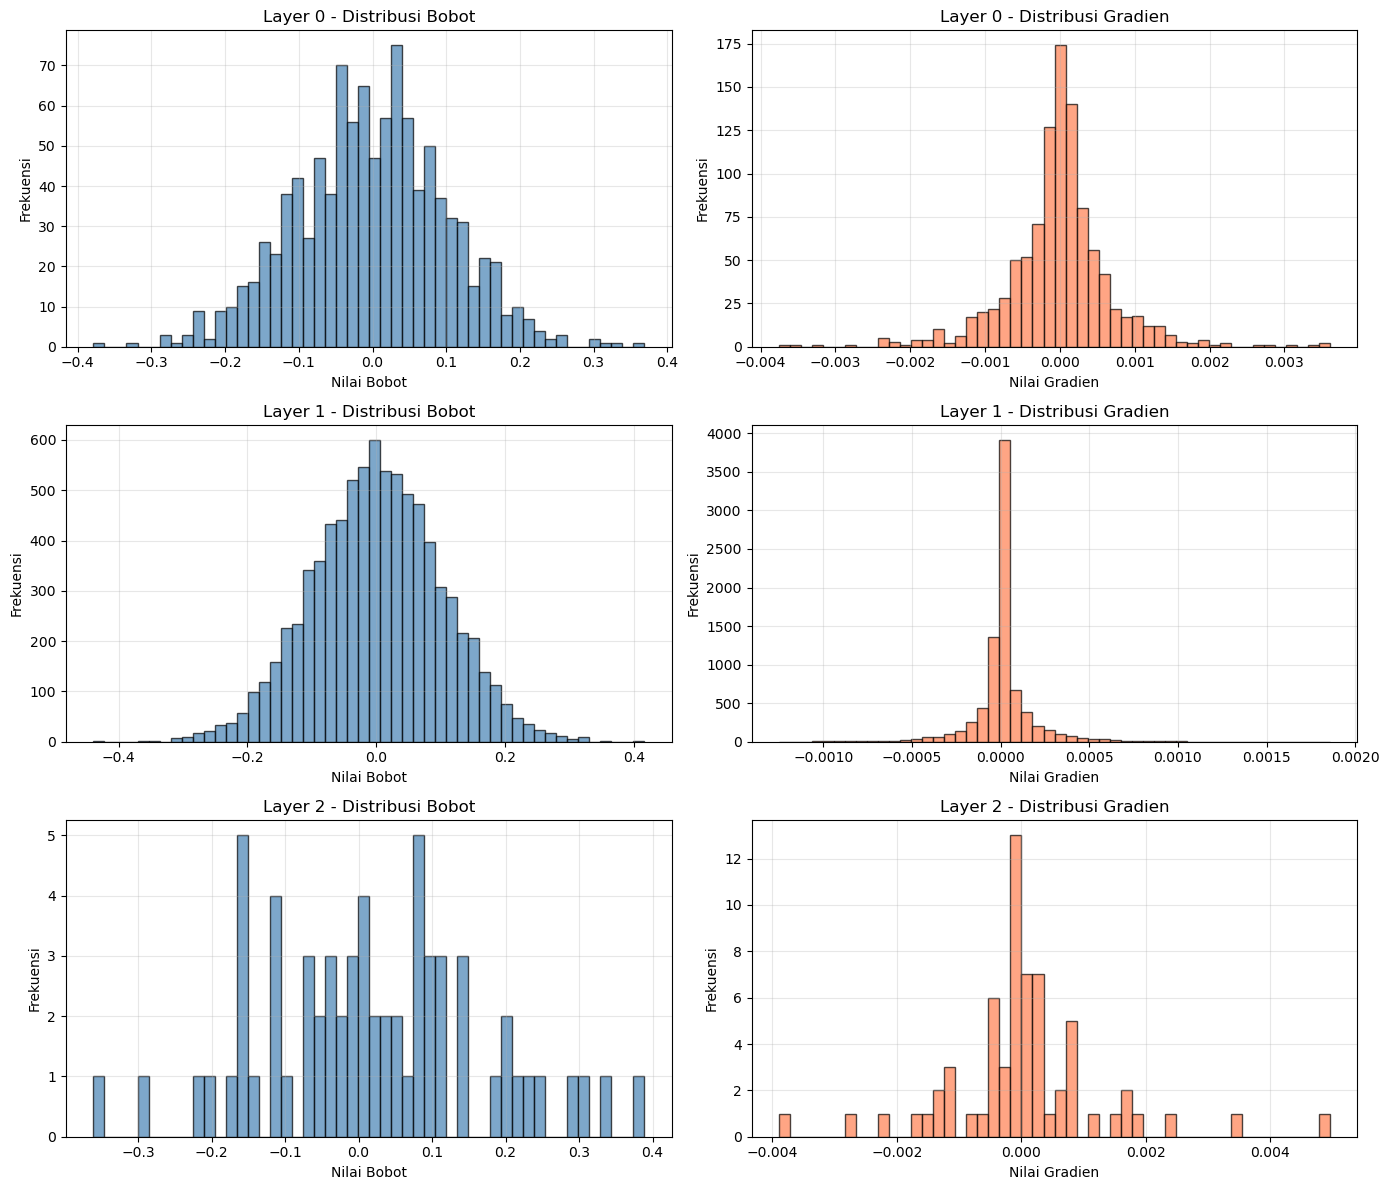


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L1
Test Accuracy: 0.7300

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002139 | Std: 0.076199
  Min: -0.347900 | Max: 0.337237
  Median: 0.000000

Layer 1:
  Shape: (128, 64)
  Mean: 0.000712 | Std: 0.073778
  Min: -0.401312 | Max: 0.379730
  Median: 0.000000

Layer 2:
  Shape: (64, 1)
  Mean: 0.015395 | Std: 0.128436
  Min: -0.342281 | Max: 0.366963
  Median: 0.000003

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000003 | Std: 0.000439
  Min: -0.002698 | Max: 0.002959
  Median: -0.000003
  % Zero Gradients: 1.56%

Layer 1:
  Shape: (12

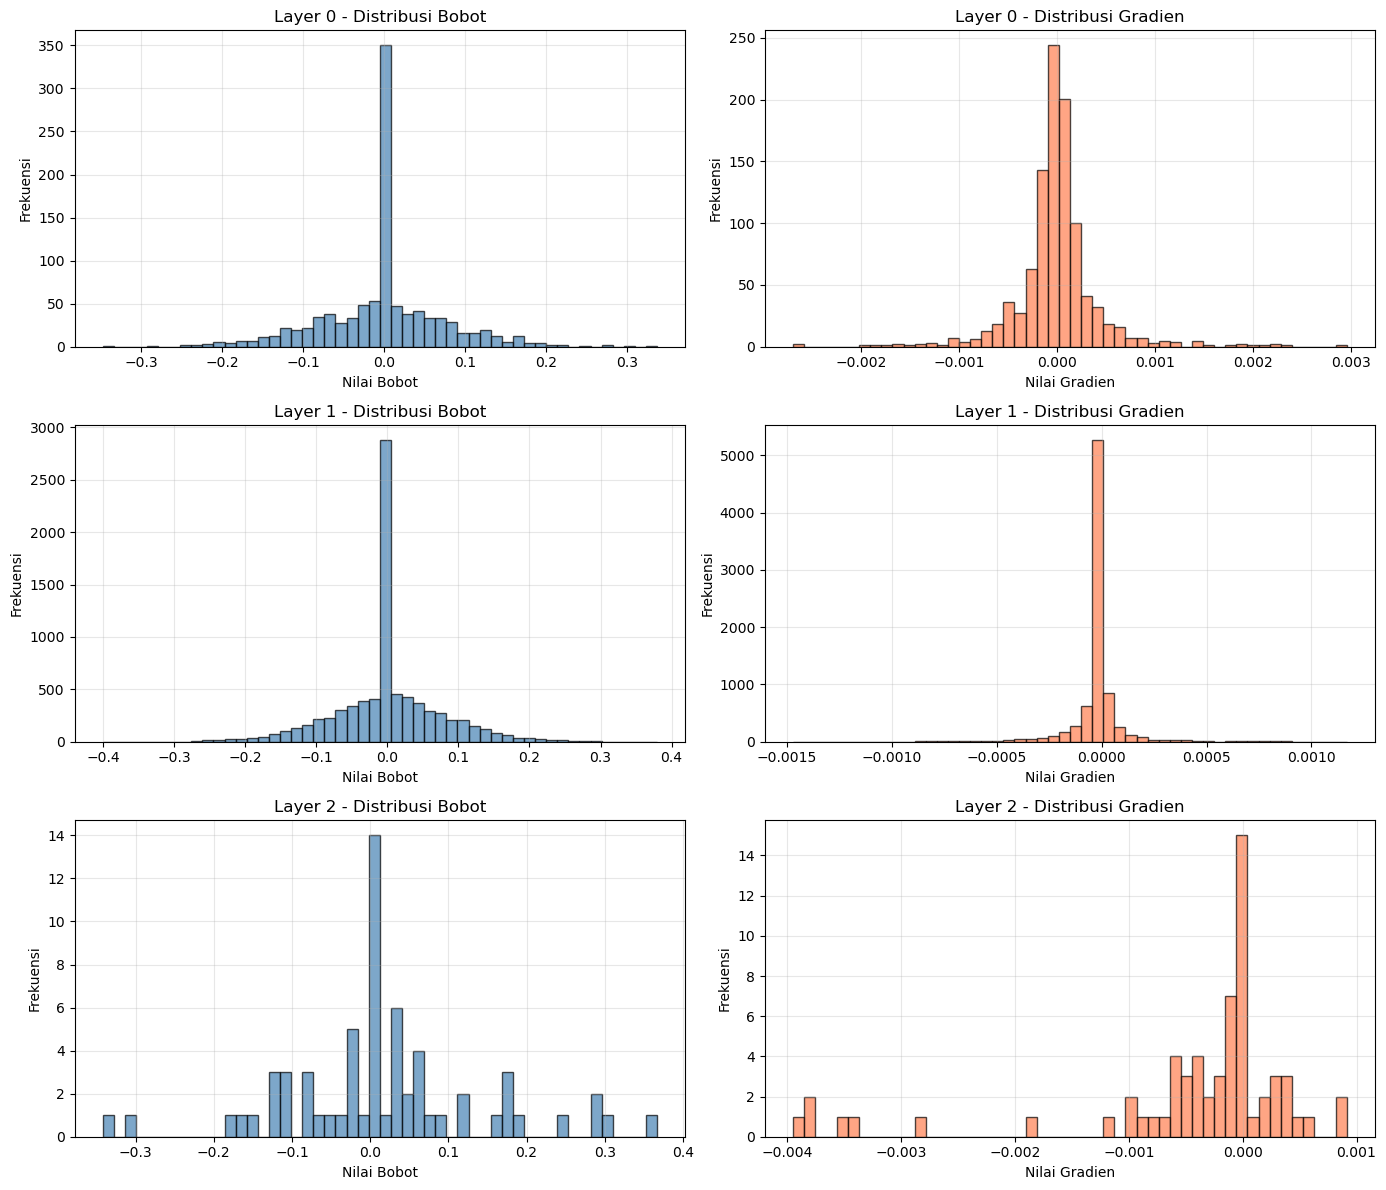


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L2
Test Accuracy: 0.7500

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002058 | Std: 0.099235
  Min: -0.365054 | Max: 0.359019
  Median: -0.001174

Layer 1:
  Shape: (128, 64)
  Mean: 0.001053 | Std: 0.097233
  Min: -0.422721 | Max: 0.401098
  Median: 0.001081

Layer 2:
  Shape: (64, 1)
  Mean: 0.017370 | Std: 0.147252
  Min: -0.355800 | Max: 0.385997
  Median: 0.008426

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000019 | Std: 0.000559
  Min: -0.004263 | Max: 0.003134
  Median: 0.000018
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

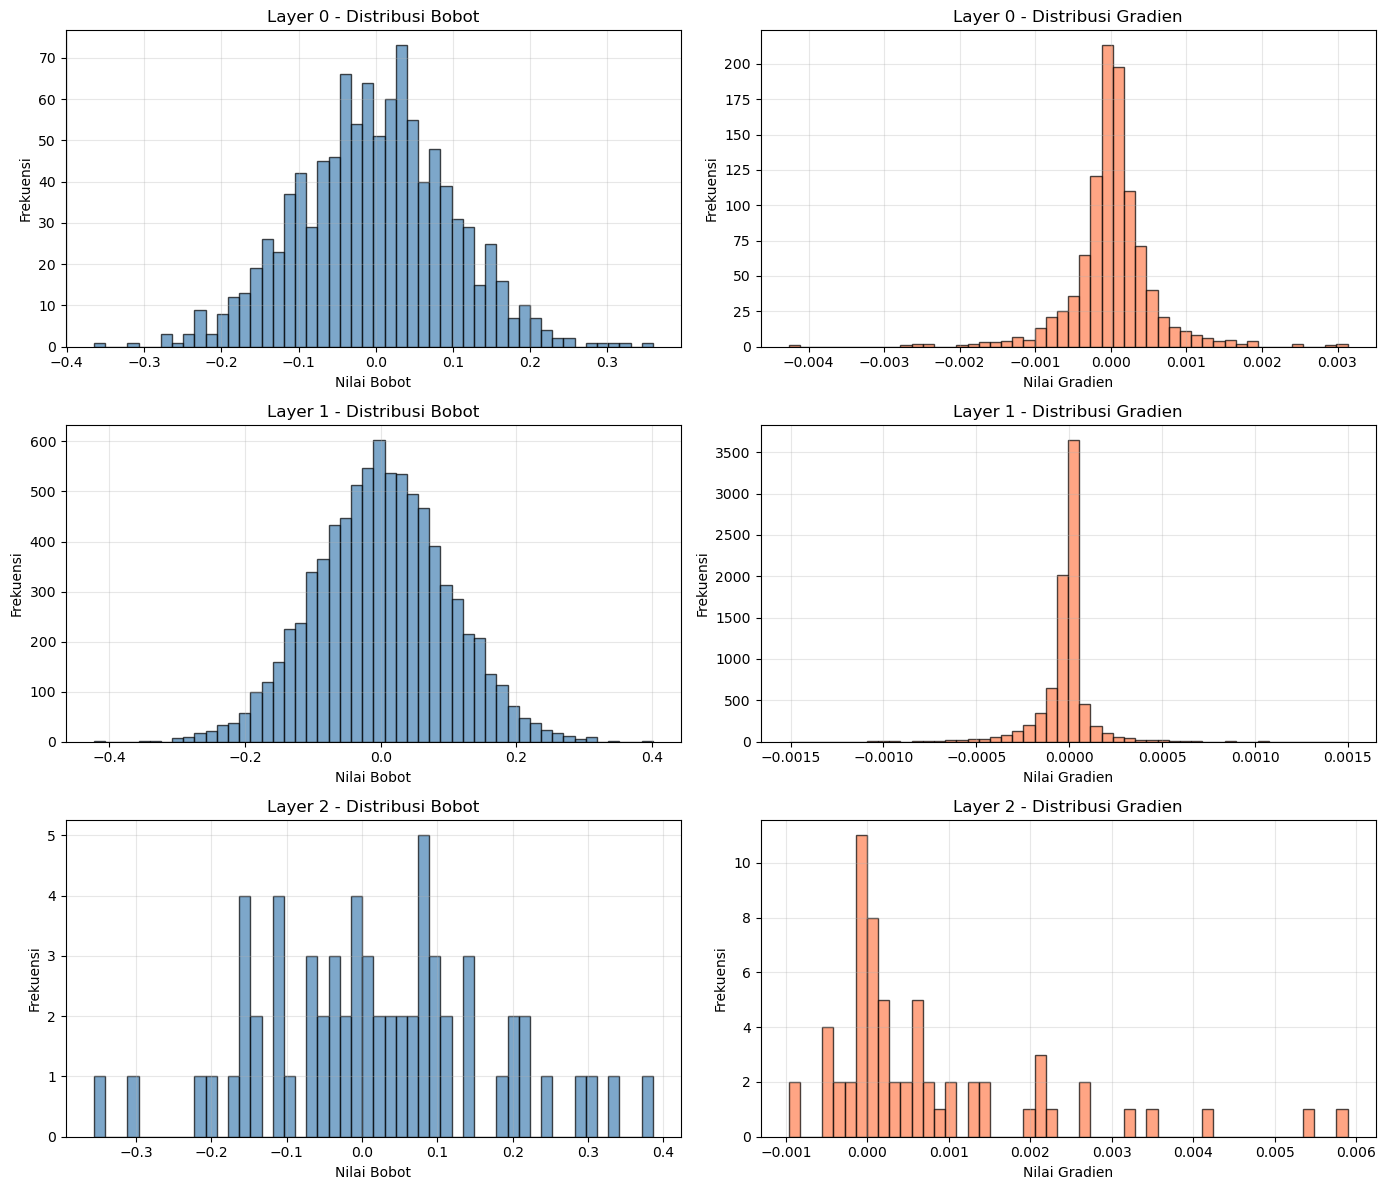

In [17]:
regularization_settings = {
    'Reg_None': {'regularization': 'none', 'lambda_': 0.0},
    'Reg_L1': {'regularization': 'l1', 'lambda_': 1e-4},
    'Reg_L2': {'regularization': 'l2', 'lambda_': 1e-4},
}

REG_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

regularization_results = {}

for exp_name, cfg in regularization_settings.items():
    one_exp = {exp_name: REG_ARCH}

    res = run_architecture_experiments(
        experiments=one_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=INIT,
        lr=0.01,
        regularization=cfg['regularization'],
        lambda_=cfg['lambda_'],
        epochs=200,
        batch_size=32,
        verbose=20,
    )

    for k, v in res.items():
        v['regularization'] = cfg['regularization']
        v['lambda_'] = cfg['lambda_']

    regularization_results.update(res)

reg_summary = pd.DataFrame([
    {
        'experiment': name,
        'regularization': result['regularization'],
        'lambda': result['lambda_'],
        'test_loss': result['test_loss'],
        'test_accuracy': result['test_accuracy'],
    }
    for name, result in regularization_results.items()
]).sort_values(by='test_accuracy', ascending=False)

print('\nRINGKASAN HASIL AKHIR PREDIKSI (REGULARISASI)')
print(reg_summary.to_string(index=False))

plot_prediction_bars(
    regularization_results,
    title_prefix='Regularization',
)

plot_train_val_curves(
    regularization_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)

analyze_results_distributions(
    regularization_results,
    result_group_name='Regularization',
)

## 4.3 Uji Perbandingan

In [18]:
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Hyperparameter
SHARED_HPARAMS = {
    'hidden_dims': (128, 64),
    'lr': 0.01,
    'batch_size': 32,
    'epochs': 200,
    'lambda_': 1e-4,
    'seed': 42,
}

# 1) Train FFNN from scratch
ffnn_arch = [
    {'n_in': n_features, 'n_out': SHARED_HPARAMS['hidden_dims'][0], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][0], 'n_out': SHARED_HPARAMS['hidden_dims'][1], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][1], 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

ffnn_result = run_architecture_experiments(
    experiments={'FFNN_Scratch': ffnn_arch},
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init={'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': SHARED_HPARAMS['seed']}},
    lr=SHARED_HPARAMS['lr'],
    regularization='l2',
    lambda_=SHARED_HPARAMS['lambda_'],
    epochs=SHARED_HPARAMS['epochs'],
    batch_size=SHARED_HPARAMS['batch_size'],
    verbose=20,
)['FFNN_Scratch']

ffnn_model = ffnn_result['model']
ffnn_prob = ffnn_model.predict(X_test)
if TASK == 'binary':
    y_true_cls = y_test.astype(int).ravel()
    y_pred_ffnn = (ffnn_prob >= 0.5).astype(int).ravel()
else:
    y_true_cls = np.argmax(y_test, axis=1)
    y_pred_ffnn = np.argmax(ffnn_prob, axis=1)

if TASK == 'binary':
    y_train_sklearn = y_train.ravel().astype(int)
else:
    y_train_sklearn = np.argmax(y_train, axis=1)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=SHARED_HPARAMS['hidden_dims'],
    activation='relu',
    solver='sgd',
    alpha=SHARED_HPARAMS['lambda_'],
    learning_rate_init=SHARED_HPARAMS['lr'],
    batch_size=SHARED_HPARAMS['batch_size'],
    max_iter=SHARED_HPARAMS['epochs'],
    random_state=SHARED_HPARAMS['seed'],
)

sk_mlp.fit(X_train, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'FFNN From Scratch',
        'Test Accuracy': np.mean(y_pred_ffnn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_ffnn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_ffnn != y_true_cls)),
    },
    {
        'Model': 'sklearn MLPClassifier',
        'Test Accuracy': np.mean(y_pred_sklearn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_sklearn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_sklearn != y_true_cls)),
    },
]).sort_values(by='Test Accuracy', ascending=False)

print('Perbandingan hasil akhir prediksi (test set):')
display(comparison_df)


Running: FFNN_Scratch
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch   20/200  loss: 0.669976  val_loss: 0.673080
Epoch   40/200  loss: 0.650842  val_loss: 0.655538
Epoch   60/200  loss: 0.633344  val_loss: 0.638010
Epoch   80/200  loss: 0.614026  val_loss: 0.617804
Epoch  100/200  loss: 0.592623  val_loss: 0.595269
Epoch  120/200  loss: 0.571695  val_loss: 0.572732
Epoch  140/200  loss: 0.553775  val_loss: 0.553169
Epoch  160/200  loss: 0.540387  val_loss: 0.538453
Epoch  180/200  loss: 0.531886  val_loss: 0.528531
Epoch  200/200  loss: 0.525568  val_loss: 0.522184

FFNN_Scratch - Test Loss: 0.5157, Accuracy: 0.7505
Perbandingan hasil akhir prediksi (test set):


,Model,Test Accuracy,Prediksi Benar,Prediksi Salah
0,FFNN From Scratch,0.7505,1501,499
1,sklearn MLPClassifier,0.6765,1353,647


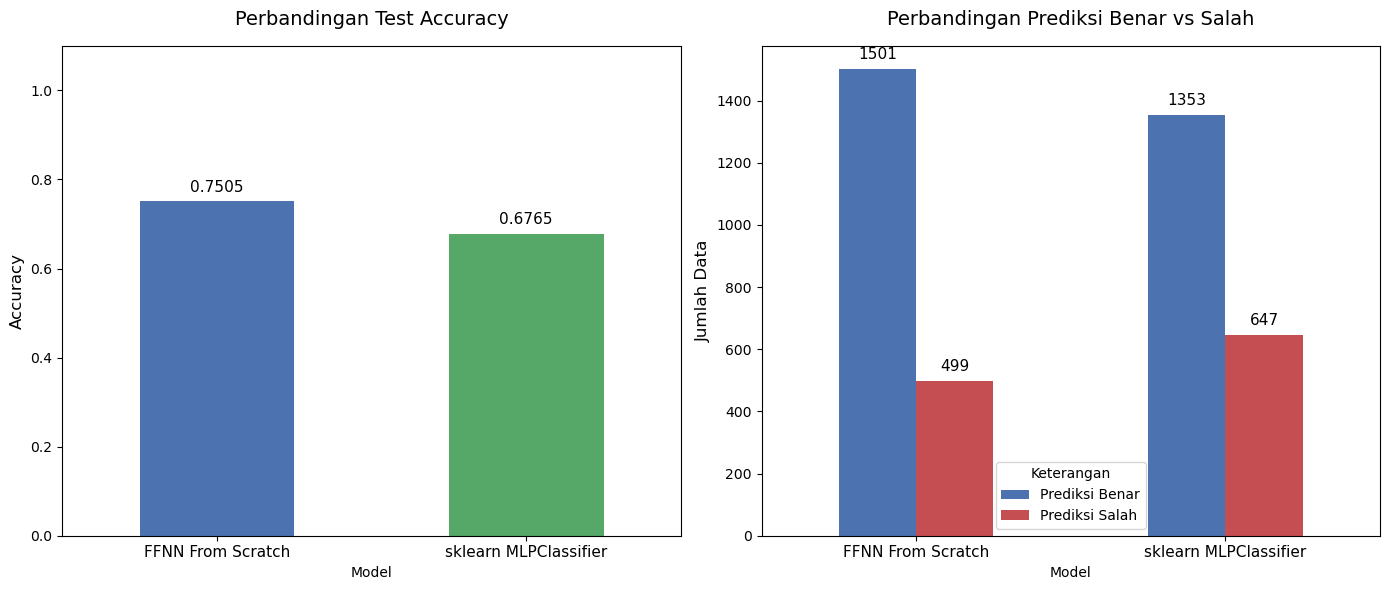

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparison_df.plot(
    x='Model', 
    y='Test Accuracy', 
    kind='bar', 
    ax=axes[0], 
    color=['#4C72B0', '#55A868'], 
    legend=False
)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=14, pad=15)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.1) 
axes[0].tick_params(axis='x', rotation=0, labelsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

comparison_df.plot(
    x='Model', 
    y=['Prediksi Benar', 'Prediksi Salah'], 
    kind='bar', 
    ax=axes[1], 
    color=['#4C72B0', '#C44E52']
)
axes[1].set_title('Perbandingan Prediksi Benar vs Salah', fontsize=14, pad=15)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Keterangan')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()